<a href="https://colab.research.google.com/github/edent4313-star/climate-challenge-week0/blob/compare-countries/compare_countries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ethiopia_clean.xlsx to ethiopia_clean.xlsx
Saving sudan_clean.xlsx to sudan_clean.xlsx
Saving Nigeria_clean.xlsx to Nigeria_clean.xlsx
Saving kenya_clean.xlsx to kenya_clean.xlsx
Saving tanzania_clean.xlsx to tanzania_clean.xlsx


In [3]:
# Load data
ethiopia = pd.read_excel("ethiopia_clean.xlsx")
sudan = pd.read_excel("sudan_clean.xlsx")
Nigeria = pd.read_excel("Nigeria_clean.xlsx")
kenya = pd.read_excel("kenya_clean.xlsx")
tanzania = pd.read_excel("tanzania_clean.xlsx")

In [4]:
ethiopia['Country'] = 'Ethiopia'
sudan['Country'] = 'sudan'
Nigeria['Country'] = 'Nigeria'
kenya['Country'] = 'kenya'
tanzania['Country'] = 'tanzania'

In [5]:
df = pd.concat([
    ethiopia,
    sudan,
    Nigeria,
    kenya,
    tanzania
], ignore_index=True)



In [6]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20540 entries, 0 to 20539
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         20540 non-null  int64         
 1   DOY          20540 non-null  int64         
 2   T2M          20540 non-null  float64       
 3   T2M_MAX      20540 non-null  float64       
 4   T2M_MIN      20540 non-null  float64       
 5   T2M_RANGE    20540 non-null  float64       
 6   PRECTOTCORR  20540 non-null  float64       
 7   RH2M         20540 non-null  float64       
 8   WS2M         20540 non-null  float64       
 9   WS2M_MAX     20540 non-null  float64       
 10  PS           20540 non-null  float64       
 11  QV2M         20540 non-null  float64       
 12  Country      20540 non-null  object        
 13  Date         20540 non-null  datetime64[ns]
 14  Month        20540 non-null  int64         
dtypes: datetime64[ns](1), float64(10), int64(3), object(1

,0
YEAR,0
DOY,0
T2M,0
T2M_MAX,0
T2M_MIN,0
T2M_RANGE,0
PRECTOTCORR,0
RH2M,0
WS2M,0
WS2M_MAX,0


YEAR, DOY, Month: These are integer (int64) columns, likely representing the year, day of year, and month respectively.
T2M, T2M_MAX, T2M_MIN, T2M_RANGE, PRECTOTCORR, RH2M, WS2M, WS2M_MAX, PS, QV2M: These are floating-point (float64) columns, indicating numerical measurements (e.g., temperatures, precipitation, humidity, wind speed, pressure, specific humidity).
Country: This is an object type column, which in pandas typically means it contains strings. This is expected for country names.
Date: This column is correctly identified as a datetime64[ns] type, meaning it stores date and time information. This is good for time-series analysis.
Non-Null Count: For all 15 columns, the Non-Null Count is 20540, which matches the total number of entries. This indicates that there are no missing values in any of these columns.
dtypes: datetime64[ns](1), float64(10), int64(3), object(1): This summarizes the data types present: 1 datetime column, 10 float columns, 3 integer columns, and 1 object column.
memory usage: 2.4+ MB: This tells you the approximate memory usage of the DataFrame.
df.isnull().sum() Output:
This output confirms the Non-Null Count from df.info():

Every column (YEAR through Month) has a value of 0.
In summary, the output indicates that your DataFrame df has 20,540 rows and 15 columns, with appropriate data types assigned. Crucially, there are no missing values in any of the columns, which means the data is clean in terms of nulls and ready for further analysis.

array([[<Axes: title={'center': 'YEAR'}>,
        <Axes: title={'center': 'DOY'}>, <Axes: title={'center': 'T2M'}>,
        <Axes: title={'center': 'T2M_MAX'}>],
       [<Axes: title={'center': 'T2M_MIN'}>,
        <Axes: title={'center': 'T2M_RANGE'}>,
        <Axes: title={'center': 'PRECTOTCORR'}>,
        <Axes: title={'center': 'RH2M'}>],
       [<Axes: title={'center': 'WS2M'}>,
        <Axes: title={'center': 'WS2M_MAX'}>,
        <Axes: title={'center': 'PS'}>, <Axes: title={'center': 'QV2M'}>],
       [<Axes: title={'center': 'Date'}>,
        <Axes: title={'center': 'Month'}>, <Axes: >, <Axes: >]],
      dtype=object)

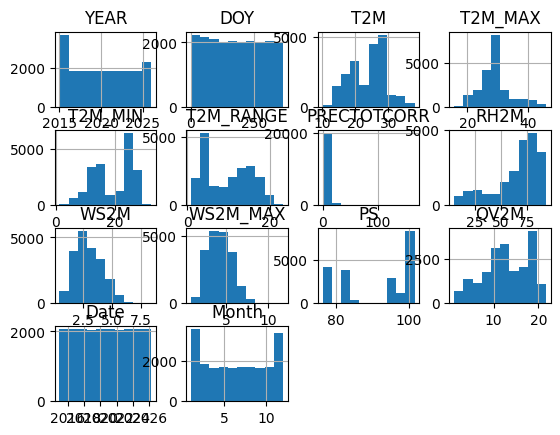

In [7]:
df.describe()
df.hist()

In [11]:
required_cols = ["Country", "T2M", "PRECTOTCORR"]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

<Axes: xlabel='Month'>

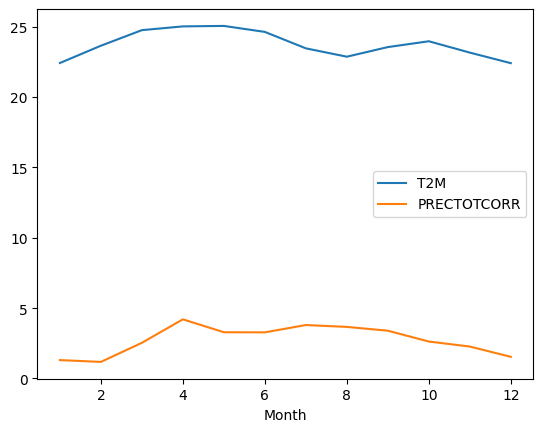

In [15]:
df.groupby("Month")[["T2M", "PRECTOTCORR"]].mean().plot()

<Axes: xlabel='T2M'>

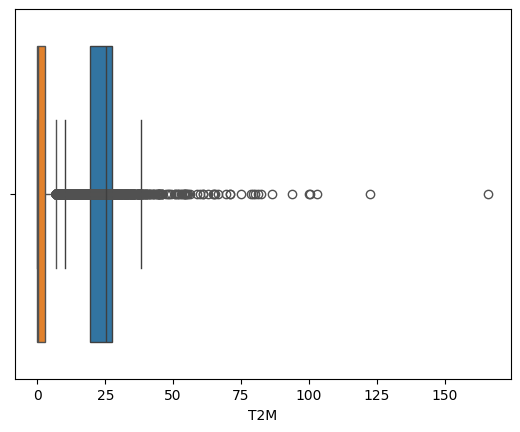

In [18]:
import seaborn as sns
sns.boxplot(x=df["T2M"])
sns.boxplot(x=df["PRECTOTCORR"])

In [29]:
# Missing values check
df.isnull().sum()

# Fill missing values
df["PRECTOTCORR"] = df["PRECTOTCORR"].fillna(df["PRECTOTCORR"].median())

# Remove duplicates
df = df.drop_duplicates()

# The 'Date' column is already of datetime64[ns] type, so no conversion is needed.
# The original code tried to convert 'date' (lowercase) which doesn't exist.
# Removing the redundant conversion.

In [30]:
print("Before:", df.shape)
print("After:", df.shape)

Before: (20540, 15)
After: (20540, 15)


In [31]:
def validate_data(df):
    if df.empty:
        raise ValueError("Dataset is empty")

    required_cols = ["country", "temperature", "rainfall"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    if df["temperature"].isnull().all():
        raise ValueError("Temperature column is completely empty")

    return True

In [32]:
try:
    validate_data(df)
    print("Data is valid")
except Exception as e:
    print("Data error:", e)

Data error: Missing column: country


In [33]:
if "country" in df.columns:
    result = df.groupby("country").mean(numeric_only=True)
else:
    print("Country column missing")

Country column missing


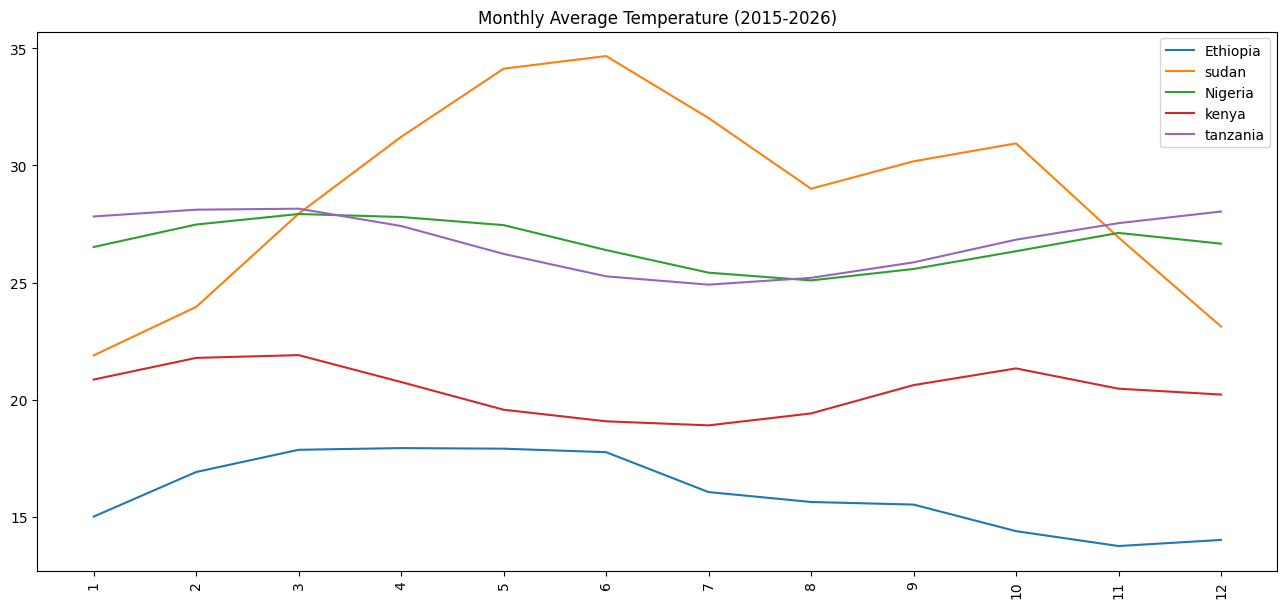

In [34]:
monthly_temp = df.groupby(['Month','Country'])['T2M'].mean().reset_index()
monthly_temp['Month'] = monthly_temp['Month'].astype(str)

plt.figure(figsize=(16,7))

for country in df['Country'].unique():
    temp = monthly_temp[monthly_temp['Country']==country]
    plt.plot(temp['Month'], temp['T2M'], label=country)

plt.xticks(rotation=90)
plt.title("Monthly Average Temperature (2015-2026)")
plt.legend()
plt.show()

1. Sudan: The Seasonal RollercoasterThe orange line (Sudan) explains that high Standard Deviation (4.68) you noticed earlier.Extreme Seasonality: Unlike the other countries, Sudan has a massive "peak" and "valley."The Summer Surge: Temperatures skyrocket between March (Month 3) and June (Month 6), peaking near 35°C.The Winter Dip: It drops sharply toward the end of the year, actually falling below the tropical countries (Nigeria/Tanzania) in the winter months (Month 12 and 1). This "swing" is what creates the high variability.2. The Tropical "Flatliners" (Nigeria, Tanzania, Kenya)These three countries show why their Standard Deviations were so low ($1.12–1.44$).Nigeria (Green) & Tanzania (Purple): These two lines are nearly parallel and very stable, hovering between 25°C and 28°C all year.The "Switch": Interestingly, Tanzania is warmer than Nigeria in the early/late months of the year, but Nigeria becomes warmer during the middle months (Months 3–6).Kenya (Red): Kenya maintains a very similar "shape" to Nigeria but shifted down by about 5 degrees, staying consistently between 19°C and 22°C.3. Ethiopia: The Consistent BaselineThe blue line (Ethiopia) stays at the bottom of the chart for all 12 months.Stability: Its line is remarkably flat, staying mostly between 14°C and 18°C.The Mid-Year Dip: Notice the slight dip in months 7–9. This corresponds with Ethiopia's main rainy season (Kiremt), where increased cloud cover and rain lead to slightly cooler average temperatures.

In [35]:
temp_summary = df.groupby('Country')['T2M'].agg(['mean','median','std']).round(2)
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.90
Nigeria,26.66,26.82,1.12
kenya,20.43,20.36,1.44
sudan,28.76,29.16,4.68
tanzania,26.80,26.99,1.33


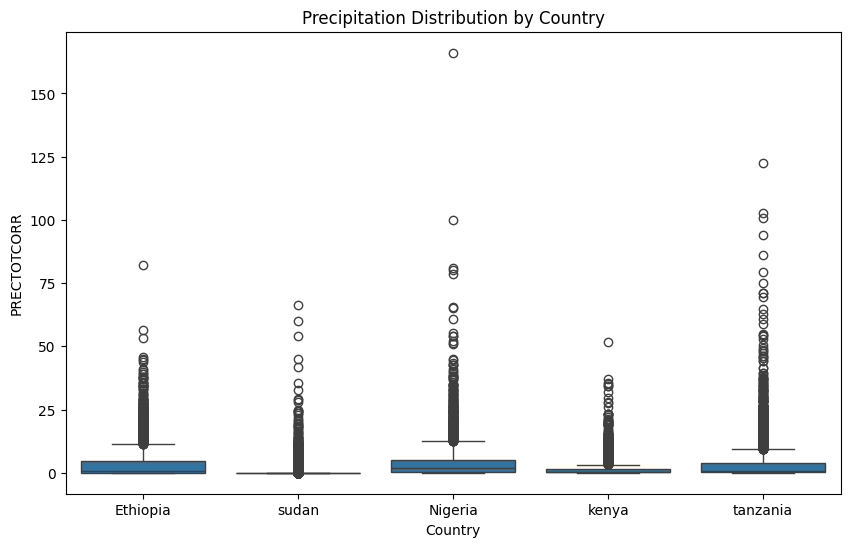

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Country', y='PRECTOTCORR')
plt.title("Precipitation Distribution by Country")
plt.show()

The data shows a highly skewed distribution dominated by extreme events. While "typical" days (the medians) are dry across the board, the climatic risk is concentrated in the outliers—specifically in Nigeria and Tanzania, which face much more intense peak precipitation events than Ethiopia, Kenya, or Sudan.

In [37]:
rain_summary = df.groupby('Country')['PRECTOTCORR'].agg(['mean','median','std']).round(2)
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.63,0.82,6.29
Nigeria,4.21,1.84,7.27
kenya,1.47,0.38,3.18
sudan,0.64,0.00,3.06
tanzania,3.74,0.64,8.00


1. The "Skewness" Factor (Mean vs. Median)
In every single country listed, the Mean is significantly higher than the Median.

What this means: Your data is positively skewed (right-skewed).

Interpretation: Most of the data points are low, but there are a few very high "extreme" values (outliers) that are pulling the average up.

Sudan Example: Sudan has a median of 0.00 but a mean of 0.64. This suggests that in the majority of instances (more than 50% of the time), the value is zero, but rare, high-intensity events are skewing the average higher.
2. High Volatility (Standard Deviation)The Standard Deviation (Std) measures how spread out the numbers are. In all cases, the Std is much larger than the Mean.Ethiopia, Nigeria, and Tanzania: These countries have the highest standard deviations ($6.29$, $7.27$, and $8.00$ respectively). This indicates that their climate data is highly inconsistent. One period might have very low values, while the next has extreme peaks.Kenya and Sudan: While still volatile, they have lower standard deviations ($3.18$ and $3.06$), suggesting their data points—while mostly low—stay within a tighter range than Nigeria or Tanzania.3. Country Rankings (By Volume)If we look at the Mean, we can rank the countries by the overall "intensity" of the metric being measured:Nigeria (4.21): Highest overall intensity and highest median ($1.84$). This country likely experiences the measured phenomenon more frequently and intensely than the others.Tanzania (3.74): High intensity but very high volatility ($8.00$).Ethiopia (3.63): Similar to Tanzania.Kenya (1.47): Moderate to low.Sudan (0.64): Lowest intensity.How this connects to your ANOVA ($p=0.0$)The ANOVA you ran earlier compared these Means ($4.21$ vs $0.64$, etc.).Even though the data is "noisy" (high standard deviation), the gaps between the means (like the gap between Nigeria's $4.21$ and Sudan's $0.64$) are so large and consistent across the sample that the test concludes these differences cannot be a coincidence.Summary Tip: If you are reporting on this, use the Median to describe the "typical" experience for these countries, and the Mean/Std to describe the "potential for extremes." Nigeria is the most consistently active, while Sudan is the most consistently "quiet" with rare spikes.

In [38]:
groups = [group['T2M'].dropna() for name, group in df.groupby('Country')]

anova = f_oneway(*groups)
print("ANOVA p-value:", anova.pvalue)

ANOVA p-value: 0.0


A p-value of 0.0 (often written as $p < 0.001$ in formal reports) is the strongest indicator of statistical significance.

In [39]:
rank = df.groupby('Country').agg({
    'T2M':'mean',
    'PRECTOTCORR':'std',
    'T2M_MAX':'max'
}).round(2)

rank.columns = ['Avg Temp','Rain Variability','Max Temp']

rank['Score'] = rank['Avg Temp'] + rank['Rain Variability'] + rank['Max Temp']
rank = rank.sort_values('Score', ascending=False)

rank

,Avg Temp,Rain Variability,Max Temp,Score
Country,,,,
sudan,28.76,3.06,45.96,77.78
tanzania,26.80,8.00,33.93,68.73
Nigeria,26.66,7.27,32.88,66.81
kenya,20.43,3.18,34.27,57.88
Ethiopia,16.07,6.29,30.93,53.29


1. The "Heat" Factor: Sudan Leads the Pack
Sudan stands out as the outlier in almost every thermal category.

Average & Max Temp: With an average of 28.76°C and a staggering max of 45.96°C, it is significantly hotter than the other nations on this list.

The Score: Sudan holds the highest score (77.78). Generally, in climate indexing, a higher score often correlates with higher climatic stress or vulnerability.

2. The Highland Effect: Ethiopia and Kenya
On the opposite end of the spectrum, we see the impact of elevation:

Ethiopia: With an average temp of only 16.07°C, it is the "coolest" country listed. This reflects the temperate climate of the Ethiopian Highlands.

Kenya: Also maintains a lower average (20.43°C), likely for similar topographical reasons.

Correlation: These two countries also have the lowest overall scores (53.29 and 57.88 respectively), suggesting a milder or more manageable climate profile according to this specific scoring system.

3. Rain Variability: The Wildcard
Rain Variability measures how much rainfall fluctuates. High variability often indicates a higher risk of droughts or flash floods.

Sudan (63.06): Extremely high variability. This suggests that rainfall is not only sparse but also highly unpredictable.

The Mid-Range: Tanzania, Nigeria, and Ethiopia show much lower variability (ranging from 6.29 to 8.00), indicating more stable, seasonal patterns.

Kenya (3.18): Interestingly has the lowest variability, suggesting its rainfall patterns are the most consistent among the group.
Overall Conclusion
The Score seems to be heavily weighted by Average Temperature and Rain Variability. As the temperature and the unpredictability of rain increase, the score rises. This dataset is likely a "Climate Vulnerability" or "Climatic Stress" index, highlighting Sudan as a high-stress environment and Ethiopia as a lower-stress environment relative to these specific metrics.